# 📊 Mission 02: Real-World Time-Series EDA & Satellite Telemetry Cleaning

## 🌌 1. The Engineering Challenge: Cloud Noise & Overlapping Orbits
In our previous simulation (Notebook 01), we worked with synthetic, noise-free curves. In production agritech deployments (like SatSure's pipelines), satellite telemetry extracted over coastal Odisha during the **Kharif Paddy Season (June to November)** suffers from heavy cloud cover, data gaps, and overlapping sensor orbits.

### 🛠️ Strategic Processing Pipeline:
1. **Deduplication:** Aggregating rows where multiple satellite orbits capture the same field on the same day.
2. **Time-Based Pivot:** Transforming the long dataset into a wide format where columns represent individual fields.
3. **Linear Interpolation:** Filling spatial-temporal gaps caused by heavy cloud masks.
4. **Savitzky-Golay (SG) Filter:** Applying a digital smoothing filter to eliminate residual high-frequency atmospheric noise while retaining critical crop phenology peaks.

In [4]:
# Step 1: Import required libraries for signal processing and EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
import os

# Step 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 🛠️ FIXED PATH: Added the missing 'MISSION_RS_SDA' parent directory
BASE_DIR = '/content/drive/MyDrive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha'
DATA_PATH = os.path.join(BASE_DIR, 'data/rasters_tabular/Odisha_Paddy_NDVI_2023_Fixed.csv')
OUTPUT_FIG_DIR = os.path.join(BASE_DIR, 'outputs/figures')

# Verify path exists before running further cells
if os.path.exists(DATA_PATH):
    print("🚀 Environment verified! File found successfully at:")
    print(f"   {DATA_PATH}")
else:
    print("❌ Error: Path is still incorrect. Please verify Google Drive mounting.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Environment verified! File found successfully at:
   /content/drive/MyDrive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha/data/rasters_tabular/Odisha_Paddy_NDVI_2023_Fixed.csv


## 🛠️ 2. Telemetry Ingestion & Aggregation
We will now load the raw `Odisha_Paddy_NDVI_2023_Fixed.csv` dataset, parse temporal vectors, and handle overlapping observations by grouping data by `date` and `name`.

In [7]:
# 1. Load the dataset (Automatically detect if it's Tab, Space, or Comma separated)
df_raw = pd.read_csv(DATA_PATH, sep=None, engine='python')

# 2. Clean completely: strip spaces from column headers AND lower-case them for safety
df_raw.columns = df_raw.columns.str.strip().str.lower()

print("📋 Columns found in your file:", list(df_raw.columns))
print("📋 Raw Data Shape:", df_raw.shape)

# 3. Convert 'date' to datetime object (using lower case 'date' now)
df_raw['date'] = pd.to_datetime(df_raw['date'])

print("\n🔍 Raw Tail Snapshot:\n", df_raw.tail(5))

# 4. Deduplicate: Group by date and field name, taking the mean of 'mean' column
# mapping to lowercase names: 'date', 'name', 'mean'
df_clean = df_raw.groupby(['date', 'name'])['mean'].mean().reset_index()
print("\n🔹 Shape after Deduplication:", df_clean.shape)

# 5. Pivot Table: Convert long format to wide format (Index = Date, Columns = Fields)
df_pivot = df_clean.pivot(index='date', columns='name', values='mean')

# 6. Reindex to a complete daily timeline to expose missing cloud gaps explicitly
full_date_range = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq='D')
df_pivot = df_pivot.reindex(full_date_range)
df_pivot.index.name = 'date'

print("\n📈 Pivoted DataFrame (First 5 Days with missing dates exposed):\n", df_pivot.head())

📋 Columns found in your file: ['date', 'name', 'mean']
📋 Raw Data Shape: (983, 3)

🔍 Raw Tail Snapshot:
           date     name      mean
978 2023-12-30  Field_1  0.254576
979 2023-12-30  Field_2  0.327742
980 2023-12-30  Field_3  0.366053
981 2023-12-30  Field_4  0.275790
982 2023-12-30  Field_5  0.364971

🔹 Shape after Deduplication: (698, 3)

📈 Pivoted DataFrame (First 5 Days with missing dates exposed):
 name         Field_1   Field_2   Field_3   Field_4   Field_5
date                                                        
2023-01-02  0.231101  0.355722  0.380932  0.253383  0.171939
2023-01-03       NaN       NaN       NaN       NaN       NaN
2023-01-04  0.173165  0.222951  0.240998  0.200551  0.217361
2023-01-05       NaN       NaN       NaN       NaN       NaN
2023-01-06       NaN       NaN       NaN       NaN       NaN


## 🧪 3. Signal Reconstruction: Time Interpolation & Savitzky-Golay Smoothing
To prepare this telemetry for deep learning models (Notebook 03), we must eliminate `NaN` gaps and smooth out sensor spikes using signal processing filters.

In [9]:
# 1. Step 1: Linear Time-based Interpolation to fill NaN gaps smoothly
df_interpolated = df_pivot.interpolate(method = 'time')

# Bfill/Ffill for any hanging edges at the absolute start or end of the year
df_interpolated = df_interpolated.bfill().ffill()

# 2. Step 2: Apply Savitzky-Golay Filter to remove high-frequency atmospheric noise
# Window length must be odd (e.g., 15 days), polyorder specifies polynomial degree (e.g., 2)
WINDOW_LENGTH = 15
POLY_ORDER = 2

df_smoothed = df_interpolated.copy()
for col in df_smoothed.columns:
    df_smoothed[col] = savgol_filter(df_interpolated[col], window_length = WINDOW_LENGTH, polyorder = POLY_ORDER)

print("✅ Data Signal Reconstruction complete!")
print("Cleaned Dataset Shape:", df_smoothed.shape)

✅ Data Signal Reconstruction complete!
Cleaned Dataset Shape: (363, 5)


## 📊 4. Phenology Mapping & Dynamic Visualizations
We will plot the raw, interpolated, and smoothed curves for a specific field to visualize the four major agronomic phases of Odisha Paddy:
1. **Transplanting (June-July)**
2. **Vegetative Acceleration (August-September)**
3. **Heading Peak (October)**
4. **Harvesting/Senescence (November-December)**

/tmp/ipykernel_3509/993006850.py:25: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3509/993006850.py:29: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.savefig(plot_output_path, dpi=300)


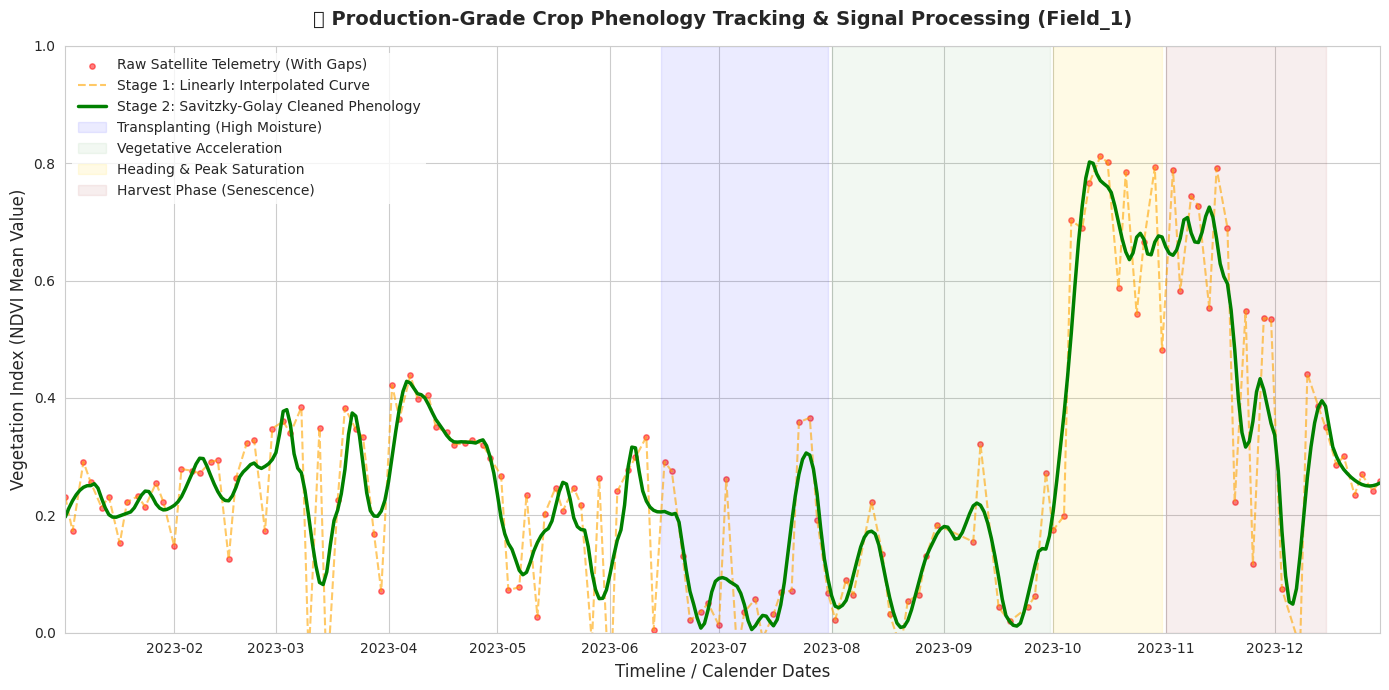

💾 Phenology chart successfully exported to: /content/drive/MyDrive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha/outputs/figures/real_paddy_phenology_curve.png


In [12]:
# Choose target field for analysis
TARGET_FIELD = 'Field_1'

plt.figure(figsize = (14, 7), dpi = 100)
sns.set_style('whitegrid')

# Plot curves to show transformation journey
plt.scatter(df_pivot.index, df_pivot[TARGET_FIELD], color='red', alpha=0.5, s=15, label='Raw Satellite Telemetry (With Gaps)')
plt.plot(df_interpolated.index, df_interpolated[TARGET_FIELD], color='orange', linestyle='--', alpha=0.6, label='Stage 1: Linearly Interpolated Curve')
plt.plot(df_smoothed.index, df_smoothed[TARGET_FIELD], color='green', linewidth=2.5, label='Stage 2: Savitzky-Golay Cleaned Phenology')

# Add context highlights for Odisha Paddy Lifecycle
plt.axvspan('2023-06-15', '2023-07-31', color='blue', alpha=0.08, label='Transplanting (High Moisture)')
plt.axvspan('2023-08-01', '2023-09-30', color='green', alpha=0.05, label='Vegetative Acceleration')
plt.axvspan('2023-10-01', '2023-10-31', color='gold', alpha=0.1, label='Heading & Peak Saturation')
plt.axvspan('2023-11-01', '2023-12-15', color='brown', alpha=0.08, label='Harvest Phase (Senescence)')

# Formatting details
plt.title(f'🌾 Production-Grade Crop Phenology Tracking & Signal Processing ({TARGET_FIELD})', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Timeline / Calender Dates', fontsize = 12)
plt.ylabel('Vegetation Index (NDVI Mean Value)', fontsize = 12)
plt.xlim(df_pivot.index.min(), df_pivot.index.max())
plt.ylim(0, 1.0)
plt.legend(loc = 'upper left', frameon = True, facecolor = 'white', edgecolor = 'none')
plt.tight_layout()

# Save analytical chart to drive outputs
plot_output_path = os.path.join(OUTPUT_FIG_DIR, 'real_paddy_phenology_curve.png')
plt.savefig(plot_output_path, dpi=300)
plt.show()

print(f"💾 Phenology chart successfully exported to: {plot_output_path}")

## 💾 5. Serializing Clean Sequential Data for Deep Learning Ingestion
Now that our time-series matrix is completely clean, continuous, and free of noise, we will save this wide-format dataset. This file will serve as the core input dataset for our **LSTM Deep Learning Predictive Engine (Notebook 03)**.

In [13]:
# Save the final cleaned dataframe
PROCESSED_DATA_PATH = os.path.join(BASE_DIR, 'data/rasters_tabular/Odisha_Paddy_Processed_Master.csv')
df_smoothed.to_csv(PROCESSED_DATA_PATH)

print(f"🎉 Success! Processed Master File saved for DL Engine at: {PROCESSED_DATA_PATH}")

🎉 Success! Processed Master File saved for DL Engine at: /content/drive/MyDrive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha/data/rasters_tabular/Odisha_Paddy_Processed_Master.csv
